<div align="center">

# Analisi dei Modelli Cosmologici con MCMC  
### (Corso di Astrofisica computazionale Laurea magistrale)

</div>

---

### Introduzione

Il programma presentato si propone di riprodurre e confrontare diversi modelli di evoluzione cosmologica a partire dalle misure di oscillazioni acustiche barioniche (BAO) in configurazione isotropica dai punti riportati nell’articolo di DESI (https://arxiv.org/pdf/
 2503.14738). In particolare, vengono analizzati i seguenti modelli: 

- **ΛCDM**  
  – Equazione di stato dell’energia oscura fissata a  
  $$w = -1$$  
  (costante cosmologica).

- **wCDM**  
  – Energia oscura con equazione di stato definita da  
  $$w \equiv \frac{P_{\rm DE}}{\rho_{\rm DE}}$$  
  costante nel tempo.

- $w_{0}w_{a}$ **CDM**  
  – Energia oscura con equazione di stato variabile:  
  $$
    w(a) = w_{0} + w_{a}\,(1 - a),
    \quad a = \frac{1}{1+z}
  $$
    – Si riduce al modello ΛCDM quando: 
  $$w_{0} = -1,\quad w_{a} = 0.$$

- **ΛCDM curvo**  
  – Stesso modello ΛCDM con  
  $$w = -1$$  
  ma con curvatura spaziale libera:  
  $$\Omega_{K} \neq 0.$$



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM, wCDM, w0waCDM
from scipy.constants import c
import emcee, corner 
import sys
sys.path.append("../")    

In [11]:
from pyACC.cosmology.distances import Distances

Tutti i modelli cosmologici, come presentato nell’articolo DESI, vengono normalizzati rispetto alla cosmologia fiduciale definita nell'articolo che ho riportato di seguito. Analogamente al programma eseguito in aula, il sound horizon è fissato al valore di questa cosmologia fiduciale, permettendo di ottenere vincoli sui parametri dei modelli.


In [12]:
C_KMS = c / 1000.0  
fid_cosmo = LambdaCDM(H0=67.14, Om0=0.3169, Ode0=1-0.3169)
r_d_fid   = 147.05 #fisso il raggio di sound horizon 

In [13]:
df = pd.read_csv("dati_desi.csv")

In [14]:
mask = df["DV_rd"].notna() & df["DV_rd_err"].notna()
if mask.sum() == 0:
    raise RuntimeError("Nessun punto BAO valido: controlla dvok.csv (DV_rd & DV_rd_err).")

df = df.loc[mask]
print(f"→ {len(df)}/{len(df)} righe BAO utilizzate.")

→ 6/6 righe BAO utilizzate.


In [15]:
z_data      = df["zeff"].to_numpy()
DV_rd_data  = df["DV_rd"].to_numpy()
DV_rd_sigma = df["DV_rd_err"].to_numpy()
alpha_data  = df["alpha_iso"].to_numpy()
alpha_sigma = df["alpha_iso_err"].to_numpy()

Per la stima dei parametri $(H_0, \Omega_m, w, w_a, \Omega_K)$ definiamo la distribuzione a posteriori  
$$
p(\theta \mid D)\;\propto\;\mathcal{L}(D \mid \theta)\,\pi(\theta)\,,
$$  
dove  
- $\mathcal{L}(D\mid \theta)$ è la **verosimiglianza**, ossia la probabilità di ottenere i dati misurati $D$ a partire da un dato insieme di parametri $\theta$,  
- $\pi(\theta)$ è il prior sui parametri.  

Campioniamo $p(\theta\mid D)$ tramite catene MCMC usando l’affine-invariant ensemble sampler implementato nella libreria open-source **emcee** originariamente creata da Dan Foreman-Mackey et al. nel 2013, che garantisce un’efficiente esplorazione dello spazio dei parametri anche in presenza di forti correlazioni. Nel blocco di codice sottostante vengono definite delle funzioni atte a calcolare questi valori che ci interessano per ottenere la posterior:

- **Prior** su $\theta$  
  La funzione prende in ingresso $\theta = (H_0, \Omega_m)$ che è l'array dei parametri (Nel primo esempio con solo il caso di modello ΛCDM è un array di due valori) e applica un prior uniforme “flat”:  
  - se i parametri cadono nell'intervallo consentito $40 < H_0 < 100\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$ e $0.05 < \Omega_m < 0.60$, allora la funzione restituisce  $\ln \pi(\theta)=0$ xhe significa  $\pi(\theta)=1$  
  - altrimenti la funzione restituisce $\ln \pi(\theta)=-\infty$ che significa $\pi(\theta)=0$

  accetta ogni coppia di parametri all'interno del box con lo stesso peso.

- **build_cosmo**  
permette di costrure la cosmologia di volta in volta a seconda del modello desiderato prendendo in ingresso l'array dei parametri e utilizzando i costruttori di cosmologie forniti dalla libreria Astropy, e permette di calcolare tutte le quantità di interesse (ad es. $H(z)$, $D_V(z)$, $r_d$, …) a partire dai parametri $\theta$.

- **LogLikelihood** è la funzione che calcola il logaritmo della likelihood. Sotto l’ipotesi di errori gaussiani indipendenti sui dati, il logaritmo della funzione di verosmiglianza si scrive come 
  $$  
    \ln \mathcal{L}(D \mid \theta)
    = -\tfrac{1}{2}\,\chi^2
  $$  
  dove il $  \chi^2$ è il residuo tra i dati e il modello diviso l'incertezza dei dati al quadrato.
 $$
    \ln\mathcal L \; = \; -\tfrac12 \sum_i
      \left[\frac{(D_V/r_d)^{\text{obs}}_i - (D_V/r_d)^{\text{mod}}_i}
    {\sigma_i}\right]^2 .
 $$
- **Log-posterior** La log-posterior si calcola semplicemente come somma di log-prior e log-likelihood:
  $$
    \ln p(\theta \mid D)
    = \ln \pi(\theta) + \ln \mathcal{L}(D \mid \theta).
  $$
  - La semplificazione di questo calcolo è uno dei motivi per cui si decide di trattare non direttamente queste funzioni ma passare dai loro logaritmi. 
  - Se la prior non è un numero finito $\ln \pi(\theta) = -\infty$ significa che $\theta$ è fuori dal prior e allora viene restituito $\ln p(\theta\mid D) = -\infty$ e la proposta viene automaticamente rigettata.  
  - Se $\theta$ è valido all’interno del prior, si ottiene semplicemente la somma dei due contributi, e la catena MCMC può accettare o rifiutare la proposta in base a questo valore.  








In [16]:
def dv_model(z, cosmo):
    Dc = cosmo.comoving_distance(z).value           # [Mpc]
    H  = cosmo.H(z).value                           # [km s⁻¹ Mpc⁻¹]
    return ( (C_KMS * z * Dc**2) / H )**(1/3)       # [Mpc]

r_d_model = 147.05 

def dv_rd_model(z, cosmo):
    return dv_model(z, cosmo) / r_d_model


def ln_prior(theta):
    H0, Om0 = theta
    if 40 < H0 < 100 and 0.05 < Om0 < 0.6:
        return 0.0  # si assume una flat prior dentro il box
    return -np.inf


def build_cosmo(theta):
    H0, Om0 = theta
    return LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0)


def ln_likelihood(theta):
    cosmo = build_cosmo(theta)
    model = dv_rd_model(z_data, cosmo)
    return -0.5 * np.sum(((DV_rd_data - model) / DV_rd_sigma)**2)


def ln_posterior(theta):
    lp = ln_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + ln_likelihood(theta)




<div align="center">

### Differenze tra l'algoritmo Metropolis–Hastings e quello di emcee (Affine‐Invariant Ensemble Sampler)

</div>

Nell’algoritmo Metropolis–Hastings si genera una catena di Markov che parte da un vettore iniziale dei parametri, chiamato $\theta_0$. supponiamo di trovarci in un punto qualsiasi della catena $\theta_i$. per avanzare si propone un piccolo spostamento intorno a $\theta_i$ e si ottiene un candidato $\theta'$. per decidere se accettare o rifiutare questo punto $\theta'$ si calcola il rapporto di accettazione  
$$
r \;=\;
\frac{\mathcal{L}(D\mid\theta')\,\pi(\theta')}{\mathcal{L}(D\mid\theta_i)\,\pi(\theta_i)}
\;\times\;
\frac{Q(\theta_i\mid\theta')}{Q(\theta'\mid\theta_i)}
$$  
che si compone di due termini: il rapporto tra le posterior e il rapporto tra le densità di proposta. Quest'ultimo detto anche fattore di Hastings, che corregge l'eventuale asimmetria del meccanismo di proposta. si estrae poi un numero casuale $u\in[0,1]$: se $r > u$ allora il candidato si aggiunge alla catena $\theta_{i+1} \to \theta'$ (accetta), altrimenti $\theta_{i+1} \to \theta_i$ (rigetta). ripetendo questi passi si ottiene una catena i cui stati campionano la distribuzione a posteriori $p(\theta\mid D)$.  

se $Q$ è simmetrica (ad esempio nel random walk classico di Metropolis–Hastings), allora  
$$
\frac{Q(\theta_i\mid\theta')}{Q(\theta'\mid\theta_i)} = 1
$$  
e la probabilità di accettazione si riduce a  
$$
r = \frac{\mathcal{L}(D\mid\theta')\,\pi(\theta')}{\mathcal{L}(D\mid\theta_i)\,\pi(\theta_i)},
$$

Nel caso dell’algoritmo implementato da **emcee**, invece di una singola catena Markoviana, si muovono in parallelo molti _walkers_.  
Il fatto che ci siano più _walkers_, oltre a essere una comodità per le tempistiche, viene anche utilizzato dall’algoritmo per proporre nuove posizioni.  
Ad ogni iterazione, per il walker $i$-esimo si sceglie un altro walker $j \neq i$ e si propone la nuova posizione allungando (o accorciando) la distanza tra $\theta_i$ e $\theta_j$ di un fattore $Z$:  
$$
\theta'_i = \theta_j + Z\,(\theta_i - \theta_j),
$$  
Questo tipo di camminata si chiama "stretch-move" proprio perchè la proposta per spostare un walker si ottiene allungando o comprimendo il vettore che lega quel walker di partenza ad un altro di un fattore casuale Z che ha una densità di probabilità data da: 
$$
g(Z)\propto \frac{1}{\sqrt{Z}}, 
\quad Z\in\bigl[\tfrac{1}{a},\,a\bigr].
$$  
e soddisfa $g(1/Z) = Zg(Z)$. Tenendo conto di ciò voglio calcolare la porbabilità di accettazione in questo algoritmo. Per farlo parto ad analizzare il rapporto tra le densità di proposta che in questo caso lo spostamento nella catena non avviene in maniera simmetrica e quindi non sarà 1. 
$$
 \frac{Q(\theta_i \rightarrow \theta'_i)}{Q(\theta'_i \rightarrow \theta_i)} = \frac{g(Z)}{g(Z^{-1})|det(J^{-1})|} 
$$
ricordando la proprietà del determinante:
$$
det(J^{-1})= \frac{1}{det(J)}
$$ 
e notando che il determinante della trasformazione lo si ricava da $\frac{d\theta'}{d\theta_i}$ allora $|det(J)|= Z^n$ ed il rapporto tra le Q diventa:
$$
 \frac{Q(\theta_i \rightarrow \theta'_i)}{Q(\theta'_i \rightarrow \theta_i)} = \frac{g(Z)}{Zg(Z)(1/Z)^n} = Z^{n-1}
$$
Questo è il fattore che si moltiplica al trapporto tra le posterior per determinare la probabilità di accettazione 
$$
r = Z^{\,n_{\rm dim}-1}\,
    \frac{\mathcal{L}(D\mid\theta'_i)\,\pi(\theta'_i)}
         {\mathcal{L}(D\mid\theta_i)\,\pi(\theta_i)},
$$

Emcee lavora in log‐space per motivi di stabilità numerica: infatti anziché calcolare direttamente $r$ e confrontarlo con $u\sim U(0,1)$, si calcola  
  $$
    \ln r
    = (n_{\rm dim}-1)\,\ln Z
    \;+\;\ln p(D\mid\theta') + \ln \pi(\theta')
    \;-\;\bigl[\ln p(D\mid\theta_i) + \ln \pi(\theta_i)\bigr]
  $$
Si estrae quindi un numero casuale $u\sim U(0,1)$ e lo si trasforma in logaritmo: $\ln u.$
La proposta viene **accettata** se $\ln u < \ln r$ altrimenti viene rigettata.  


<div align="center">

## Esempio 1: per il modello ΛCDM  

</div>


Nella seguente parte del notebook si esegue il campionamento utilizzando emcee siamo interessati al modello ΛCDM quindi l'obiettivo è quello di stimare i due parametri liberi $H_0$ e $\Omega_m$.  Impostiamo quindi `ndim = 2` e per il campionamento usiamo `nwalk = 32`: in pratica lanciamo **32
catene parallele** (i walkers). Ogni catena viene fatta evolvere per `nsteps = 5000` passi. Dei campioni prodotti scarteremo i primi `burn = 2000` passi questa fase di
*burn-in* serve a eliminare la dipendenza dalle condizioni iniziali. 

I walkers non partono da un singolo “guess” ma da posizioni uniformemente
estratte nel box-prior $40 < H_0 < 100 \; km^{-1} \; Mpc^{-1}$ e $0.05 < \Omega_m < 0.60$,
evitando qualsiasi bias iniziale

Il campionamento vero e proprio inizia con la creazione dell’oggetto `sampler`, che richiede il numero di walker (`nwalk = 32`), la dimensionalità dello spazio dei parametri (`ndim = 2`) e la funzione `ln_posterior`. il sampler implementa l’algoritmo affine-invariant di **`emcee`**. Quello che si effettua di seguito è lo srotolamento post-burn-in ovvero si costruisce la catena `flat_chain = sampler.get_chain(discard=burn, flat=True)`  scartando i primi `burn = 2000` passi e appiattendo l’array. Questo procedimento è fondamentale per poter effettuare dei calcoli (come la mediana) sui valori della catena perchè permette di creare due colonne (una per parametro) con tutti i campioni esclusi i 2000 iniziali. 

La stima puntuale dei parametri viene calcolata come la mediana di ogni colonna della mia flat_chain.  
`best_H0, best_Om0 = np.median(flat_chain, axis=0)` . Con i valori mediani creiamo l’oggetto Astropy `LambdaCDM`
corrispondente, imponendo la piattezza ($\Omega_\Lambda = 1 - \Omega_m$). Questa cosmologia verrà impiegata per
tracciare la curva teorica e calcolare gli intervalli di confidenza nel confronto con i dati BAO.



In [17]:
ndim  = 2
nwalk = 32
nsteps = 5000
burn   = 2000
rng    = np.random.default_rng(42)

p0 = rng.uniform(low=[40,0.05], high=[100,0.6], size=(nwalk, ndim))
sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior)
sampler.run_mcmc(p0, nsteps, progress=True)
flat_chain = sampler.get_chain(discard=burn, flat=True)
best_H0, best_Om0 = np.median(flat_chain, axis=0) #la mediana della flat chain lungo le due colonne
cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)

100%|██████████| 5000/5000 [02:34<00:00, 32.42it/s]


### Diagnostica 1
Quando si esegue una catena MCMC, all’inizio i punti generati non sono indipendenti. La catena di ogni walker parte da un punto $p_0$ che spesso **non** si trova nella regione di massima probabilità: è necessario che quindi la catena raggiunga la distribuzione stazionaria e serve tempo perchè i campioni siano ben distribuiti e non troppo correlati. In questa fase diagnostica, che precede la stima dei parametri e la visualizzazione delle trace plot, si cerca di capire se la catena è convergente e se ci sono abbastanza campioni indipendenti per ottenere stime affidabili; in caso contrario si continua a generare nuovi punti fino a raggiungere una statistica migliore.

Per valutare la correlazione tra campioni si utilizza la funzione di autocorrelazione di un generico processo $x(t)$, definita da  
$$
f(\tau) = \displaystyle \int_{-\infty}^{+\infty} x(t)(x(t+\tau)) \, dt
$$
Idealmente, per campioni indipendenti, $f(\tau)\approx 0$ per $\tau>0$. Risulta utile misurare, in unità di passi della catena, quanto tempo serve perché la catena “dimentichi” la condizione iniziale. Emcee fornisce la funzione `sampler.get_autocorr_time(discard=burn)` che restituisce proprio $\tau_{\rm int}$ in unità di passi della catena. Se ottengo un tempo di autocorrelazione $\tau$, il numero di campioni indipendenti (effettivi) si stima come  
$$
N_{\rm eff} \;=\; \frac{N_{\rm passi}}{\tau}\,.
$$  
Per garantire stime affidabili dei parametri si usa la regola empirica  
$$
N_{\rm eff}\;\ge\;50.
$$  
Un $N_{\rm eff}$ sufficientemente alto significa che l’autocorrelazione è caduta rapidamente e che la catena ha esplorato lo spazio dei parametri fino alla distribuzione stazionaria. In questo caso le stime dei parametri risultano stabili da iterazione a iterazione e si considera la catena **convergente**. Se invece $N_{\rm eff}<50$, ci sono troppi campioni correlati, la catena non ha ancora “dimenticato” il punto di partenza e diventa necessario proseguire il campionamento finché non si ottiene una statistica più consistente. `get_autocorr_time()` fornisce un valore di $\tau$ per ciascun parametro: $\tau_{\theta_1}$ e $\tau_{\theta_2}$. per stimare il numero di campioni indipendenti $N_{\rm eff}$ si utilizza il valore di $\tau$ massimo tra i due denominato $\tau_{\max}$, in modo da garantire che anche il parametro con la più lenta decorrelazione disponga di un numero sufficiente di passi efficaci per mescolarsi completamente. se il max è coperto di conseguenza lo saranno anche tutti gli altri. 


**L’acceptance rate** è la frazione di proposte che la catena MCMC accetta rispetto al totale di mosse tentate. Con l’algoritmo di emcee, un valore di acceptance rate compreso grosso modo tra 0.2 e 0.5 è considerato ideale. Se l’acceptance rate scende sotto ~0.1, la catena fatica a muoversi e rischia di rimanere intrappolata in zone locali; se invece supera ~0.8, i passi sono troppo piccoli e si producono troppi campioni praticamente ridondanti. Mantenere l’acceptance rate in questo intervallo garantisce quindi un buon compromesso tra esplorazione rapida e indipendenza dei campioni.



In [18]:
try:
    tau = sampler.get_autocorr_time(tol=0.05)
except emcee.autocorr.AutocorrError:
    print("tau non stimabile ")
    tau = np.full(sampler.ndim, 100.0)

tau_max = np.max(tau)
tau_min = np.min(tau)
n_steps = sampler.iteration
n_indep  = int(n_steps / tau_max)
burnin   = int(2 * tau_max)
thin     = max(int(0.5 * tau_min), 1)
acc_frac = np.mean(sampler.acceptance_fraction)

print(f"tau:            {tau}")
print(f"Passi totali:   {n_steps}")
print(f"Indipendenti:   {n_indep}")
print(f"Acceptance:     {acc_frac:.3f}")


tau:            [28.58520589 31.374108  ]
Passi totali:   5000
Indipendenti:   159
Acceptance:     0.714


### Diagnostica 2 

Nella seconda fase di diagnostica verifichiamo il burn-in, approssimato come  
$$
\mathrm{burn\text{-}in} \approx 2\,\tau_{\max},
$$  
e tracciamo il trace plot dei parametri sovrapponendo una linea verticale in corrispondenza di questo valore. In tal modo controlliamo visivamente che, al momento del burn-in, le catene abbiano effettivamente perso memoria del punto di partenza e si siano stabilizzate nella regione di massima posteriori.


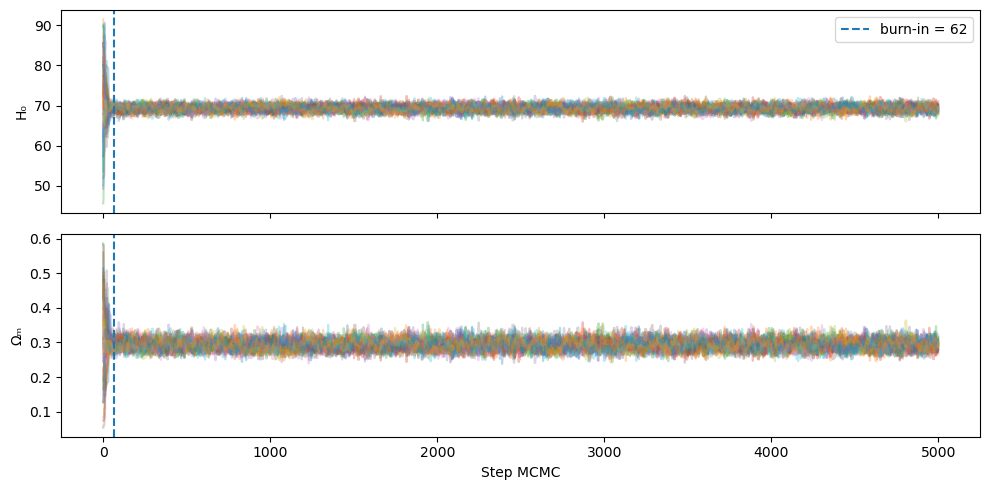

In [19]:
chain = sampler.get_chain()
n_steps, n_walkers, ndim = chain.shape
burnin   = int(2 * tau_max)

if ndim == 2:
    labels = ["H₀", "Ωₘ"]
else:
    labels = [f"θ_{i}" for i in range(ndim)]

fig, axes = plt.subplots(ndim, 1, sharex=True, figsize=(10, 2.5 * ndim))
axes = np.atleast_1d(axes)

for ax, label, i in zip(axes, labels, range(ndim)):
    for w in range(n_walkers):
        ax.plot(chain[:, w, i], alpha=0.3)
    ax.axvline(burnin, linestyle='--', label=f"burn-in = {burnin}")
    ax.set_ylabel(label)
    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Step MCMC")
plt.tight_layout()
plt.show()

Dopo aver verificato la consistenza della catena, si ricavano i **valori centrali e incertezze a $1\sigma$** per i due
parametri campionati, $H_0$ e $\Omega_m$.

* `np.percentile(flat_chain[:, 0], [16, 50, 84])` restituisce il
  16°, 50° (mediana) e 84° percentile della distribuzione a posteriori
  di $H_0$; la stessa operazione sulla seconda colonna fornisce i
  percentili per $\Omega_m$.

* Le incertezze sono calcolate come scarti asimmetrici:

  $$
  \sigma_{+} = P_{84} - P_{50}, \qquad
  \sigma_{-} = P_{50} - P_{16},
  $$

  dove $P_{q}$ indica il $q$-esimo percentile.  
  Questa scelta è adatta a posterior non perfettamente simmetriche.


il numero centrale del print finale è la mediana e i termini “$+\sigma_{+}$”,
“$-\sigma_{-}$” rappresentano l’intervallo di credibilità al 68 %
(l’equivalente Bayesiano del $1\sigma$ gaussiano, ma calcolato senza
assumere simmetria della distribuzione).





In [20]:
H0_16, H0_50, H0_84   = np.percentile(flat_chain[:, 0], [16, 50, 84])
Om0_16, Om0_50, Om0_84 = np.percentile(flat_chain[:, 1], [16, 50, 84])

H0_err_plus  = H0_84 - H0_50
H0_err_minus = H0_50 - H0_16
Om_err_plus  = Om0_84 - Om0_50
Om_err_minus = Om0_50 - Om0_16

print(f"H0   = {H0_50:.2f}  +{H0_err_plus:.2f}  -{H0_err_minus:.2f}  km/s/Mpc")
print(f"Ω_m  = {Om0_50:.3f} +{Om_err_plus:.3f} -{Om_err_minus:.3f}")

H0   = 69.35  +0.82  -0.83  km/s/Mpc
Ω_m  = 0.293 +0.015 -0.015


## Plot BAO iso e visualizzazione delle curve

### PLOT 1
Per mostrare la distribuzione delle traiettorie **post burn-in** in modo rapido ed efficace, si estrae un sottoinsieme casuale di **800** campioni dalla catena piatta (`flat_chain`). Questa operazione riduce il carico di plotting senza perdere l’informazione statistica. Ciascun campione $\theta_j$ genera una curva  
$$
  a_{iso,j} = \frac{D_V(z;\,\theta_j)}{D_V^{\rm fid}(z)}\,r_d
$$ 
valutata su un vettore di 400 valori di redshift $z$. Impilando queste 800 curve, si ottiene una matrice di dimensione (800 × 400), dove ogni riga corrisponde a una traiettoria $a_{iso, j}$. Su questo insieme di curve si calcola la **mediana** lungo l’asse delle righe che viene poi plottata in sovrimpressione con una linea tratteggiata. Il “tappeto” di curve, unitamente alla curva mediana, viene quindi sovrapposto ai dati BAO isotropici per visualizzare la dispersione delle previsioni e confrontarla con le osservazioni.  

### PLOT 2
Nel secondo plot viene tracciata la curva **best-fit** $a_{\rm iso}(z)$ ottenuta utilizzando i parametri mediana $ H_0 = \texttt{best\_H0},\; \Omega_m = \texttt{best\_Om0} $ ncostruendo con essi la cosmologia $\Lambda$ CDM corrispondente e calcolando nuovamente 
$$
a_{\rm iso}(z)
= \frac{D_V(z;\,H_0,\Omega_m)}{D_V^{\rm fid}(z)}\,r_d^{\rm fid}.
$$ 
L’intervallo di incertezza 16°–84° percentile non è calcolato attorno alla curva best-fit, ma a partire dalla **mediana delle 800 traiettorie** selezionate, per motivi di velocità di plotting, garantendo comunque una rappresentazione affidabile della dispersione dei campioni.






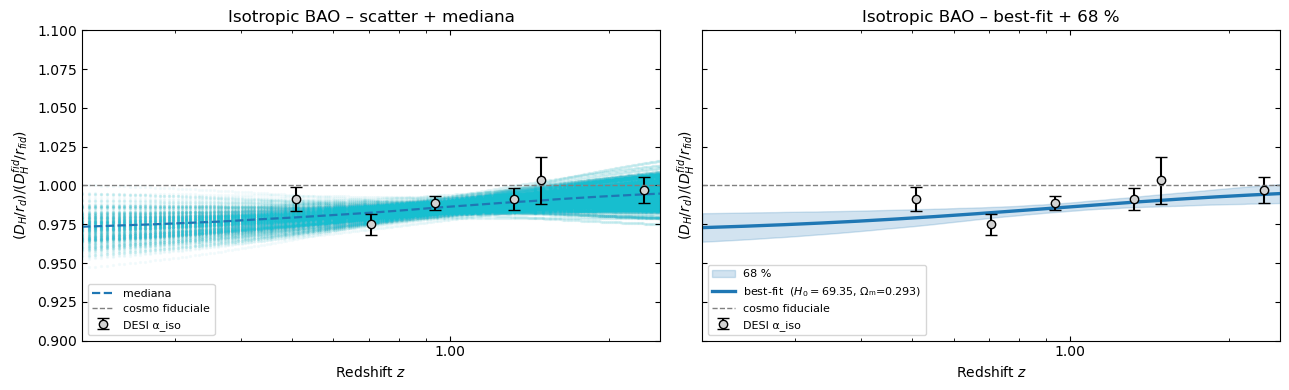

In [21]:
from matplotlib.ticker import ScalarFormatter

z_dense      = np.linspace(0.2, 2.5, 400) #un vettore di 400 punti equispaziati tra 0.2 e 2.5
Dv_fid_dense = dv_model(z_dense, fid_cosmo) #DV della cosmologia fiduciale per i punti z_dense

n_band   = min(800, flat_chain.shape[0]) # limito a 800 il numero di campioni da usare per disegnare la banda di incertezza
idx_band = rng.choice(flat_chain.shape[0], size=n_band, replace=False) # indici casuali (senza ripetizione) che selezionano n_band righe da flat_chain.

alpha_mat = np.array([
    dv_rd_model(z_dense, build_cosmo(theta)) / (Dv_fid_dense / r_d_fid)
    for theta in flat_chain[idx_band] # per ogni riga di flat_chain[idx_band] calcola il DV normalizzato
])   

idx_all = np.arange(flat_chain.shape[0])

alpha_med  = np.median(alpha_mat, axis=0) # mediana dei n_band valori di α
alpha_low  = np.percentile(alpha_mat, 16, axis=0)
alpha_high = np.percentile(alpha_mat, 84, axis=0)

# parametri mediani curva best-fit
best_H0, best_Om0 = np.median(flat_chain, axis=0)
cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)
alpha_best = dv_rd_model(z_dense, cosmo_best) / (Dv_fid_dense / r_d_fid)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

scat_idx = rng.choice(n_band, size=min(300, n_band), replace=False) #di un sotto-insieme di 300 traiettorie per dare un’idea della dispersione delle catene.
axL.scatter(np.tile(z_dense, scat_idx.size),
            alpha_mat[scat_idx].ravel(),
            s=2, alpha=0.04, color="tab:cyan")
axL.plot(z_dense, alpha_med, ls="--", lw=1.6,
         color="tab:blue", label="mediana ")

axL.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axL.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axL.set_title("Isotropic BAO – scatter + mediana")

# best-fit + 68 %
axR.fill_between(z_dense, alpha_low, alpha_high,
                 color="tab:blue", alpha=0.20, label="68 % ")
axR.plot(z_dense, alpha_best, lw=2.4, color="tab:blue",
         label=fr"best-fit  ($H_0={best_H0:.2f}$, Ωₘ={best_Om0:.3f})")

axR.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axR.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axR.set_title("Isotropic BAO – best-fit + 68 %")


for ax in (axL, axR):
    ax.set_xscale("log")
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r'$(D_H/r_d)/(D_H^{fid}/r_{fid})$')
    ax.set_xlim(0.2, 2.5)
    ax.set_ylim(0.9, 1.1)

    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True,
                   labeltop=False, labelright=False)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.xaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.yaxis.get_major_formatter().set_useOffset(False)

    ax.legend(fontsize=8, loc='lower left')

fig.tight_layout()
plt.show()


<div align="center">

## Esempio 2: Estensione a diversi modelli cosmologici

</div>

Adesso si ripete lo stesso procedimento (inizializzazione dei walker, definizione di prior e posterior, esecuzione delle catene MCMC) per ciascuno dei modelli:  
- ΛCDM flat  
- wCDM flat  
- $w_{0}w_{a}$ CDM flat  
- ΛCDM curvo ($\Omega_K \neq 0$)  

Una funzione dedicata costruisce, per ogni modello, l’array $\theta$ adeguato, adattando automaticamente il numero di parametri e i limiti del prior uniforme. Allo stesso modo, `build_cosmo_new(theta, tag)` genera l’oggetto cosmologia corrispondente. Variando la definizione della prior e di conseguenza della posterior in funzione del modello, è possibile lanciare catene MCMC indipendenti per stimare i parametri specifici di ciascuna cosmologia.  



In [22]:
from astropy.cosmology import LambdaCDM, wCDM, w0waCDM

In [32]:
models = {
    "LCDM_flat"   : dict(ndim=2,  tag="lcdm",      color="black"),
    "wCDM_flat"   : dict(ndim=3,  tag="wcdm",      color="cyan"),
    "w0waCDM_flat"   : dict(ndim=4,  tag="w0wa_des",  color="green"),
    #"w0wa_lit"    : dict(ndim=4,  tag="w0wa_lit",  color="red"),
    "LCDM_Ok"     : dict(ndim=3,  tag="lcdm_ok",   color="purple"),
   # "w0wa_Ok"     : dict(ndim=5,  tag="w0wa_ok",   color="orange"),
}

In [ ]:
from astropy.cosmology import LambdaCDM, FlatwCDM, Flatw0waCDM

# Range consentito per i parametri cosmologici
bounds_new = dict(
    H0=(30.0, 110.0), Om=(0.01, 0.80),
    Ok=(-0.30, 0.30),  w0=(-2.5, -0.3), wa=(-5.0, 2.0)
)

def unpack_theta(theta, tag):
    if "lcdm" in tag and "ok" not in tag and "w0wa" not in tag and "wcdm" not in tag:
        return {"H0": theta[0], "Om": theta[1], "Ok": None,   "w0": None,   "wa": None}
    if "lcdm" in tag and "ok" in tag:
        return {"H0": theta[0], "Om": theta[1], "Ok": theta[2], "w0": None,   "wa": None}
    if "wcdm" in tag and "ok" not in tag:
        return {"H0": theta[0], "Om": theta[1], "Ok": None,   "w0": theta[2], "wa": None}
    if "wcdm" in tag and "ok" in tag:
        return {"H0": theta[0], "Om": theta[1], "Ok": theta[2], "w0": theta[3], "wa": None}
    if "w0wa" in tag and "ok" not in tag:
        return {"H0": theta[0], "Om": theta[1], "Ok": None,   "w0": theta[2], "wa": theta[3]}
    if "w0wa" in tag and "ok" in tag:
        return {"H0": theta[0], "Om": theta[1], "Ok": theta[2], "w0": theta[3], "wa": theta[4]}
    raise ValueError(f"Tag non riconosciuto: {tag}")

def ln_prior_new(theta, tag):
    p = unpack_theta(theta, tag)
    if not (30.0 < p["H0"] < 110.0 and 0.01 < p["Om"] < 0.80):
        return -np.inf
    if p["Ok"] is not None:
        if not (-0.30 < p["Ok"] < 0.30):
            return -np.inf
        # Omega_L >= 0
        if 1.0 - p["Om"] - p["Ok"] <= 0:
            return -np.inf
    if p["w0"] is not None and not (-2.5 < p["w0"] < -0.3):
        return -np.inf
    if p["wa"] is not None and not (-5.0 < p["wa"] < 2.0):
        return -np.inf
    return 0.0

def build_cosmo_new(theta, tag):
    p = unpack_theta(theta, tag)
    if "lcdm" in tag and "ok" not in tag and "w0wa" not in tag and "wcdm" not in tag:
        return LambdaCDM(H0=p["H0"], Om0=p["Om"], Ode0=1.0 - p["Om"])
    if "lcdm" in tag and "ok" in tag:
        Ode0_val = 1.0 - p["Om"] - p["Ok"]
        return LambdaCDM(H0=p["H0"], Om0=p["Om"], Ode0=Ode0_val)
    if "wcdm" in tag and "ok" not in tag:
        return FlatwCDM(H0=p["H0"], Om0=p["Om"], w0=p["w0"])
    if "wcdm" in tag and "ok" in tag:
        Ode0_val = 1.0 - p["Om"] - p["Ok"]
        return LambdaCDM(H0=p["H0"], Om0=p["Om"], Ode0=Ode0_val)
    if "w0wa" in tag and "ok" not in tag:
        return Flatw0waCDM(H0=p["H0"], Om0=p["Om"], w0=p["w0"], wa=p["wa"])
    if "w0wa" in tag and "ok" in tag:
        Ode0_val = 1.0 - p["Om"] - p["Ok"]
        return Flatw0waCDM(H0=p["H0"], Om0=p["Om"], w0=p["w0"], wa=p["wa"])
    raise ValueError(f"Tag non riconosciuto: {tag}")

def ln_likelihood_new(theta, tag):
    lp = ln_prior_new(theta, tag)
    if not np.isfinite(lp):
        return -np.inf
    try:
        cosmo = build_cosmo_new(theta, tag)
        model = dv_rd_model(z_data, cosmo)
        if not np.all(np.isfinite(model)):
            return -np.inf
        chi2 = np.sum(((DV_rd_data - model) / DV_rd_sigma)**2)
        ll = -0.5 * chi2
        return ll if np.isfinite(ll) else -np.inf
    except Exception:
        return -np.inf

def ln_posterior_new(theta, tag):
    return ln_likelihood_new(theta, tag)


Adesso si esegue il campionamento dei quattro modelli cosmologici sempre utilizzando **emcee**, ma con alcune differenze rispetto all’Esempio 1.
La prima riguarda il numero di walker e di passi per ciascuna catena:
$$
n_{\rm walk} = \max\bigl(4\,n_{\rm dim},\,20\bigr),
\qquad
n_{\rm steps} =
\begin{cases}
2000, & n_{\rm dim} \le 2,\\
5000, & n_{\rm dim} > 2.
\end{cases}
$$

Il campionamento viene modificato aggiungendo l’attributo:
```python
moves = emcee.moves.StretchMove(a=3.0)
```
Il parametro $a$ definisce l’intervallo da cui si estrae il fattore di scala $Z \in \bigl[\tfrac{1}{a},\,a\bigr].$ 
Di default $a=2$, per cui $Z\in[0.5,2]$; impostando $a=3$, otteniamo $Z\in[\tfrac{1}{3},3]$, quindi il fattore di “allungamento” o “accorciamento” tra i due walker può essere molto più estremo. Viene proporsto questo cambiamento perché, aumentando il numero dei parametri, questi presentano correlazioni piuttosto forti e la distribuzione a posteriori è “stretta” lungo certe direzioni: usando un $a$ più grande si allarga di conseguenza l’intervallo $\bigl[\tfrac{1}{a},\,a\bigr]$ da cui viene estratto $Z$, permettendo ai walker di compiere salti più ampi e uscire più rapidamente dalle regioni locali.All’aumentare di $a$ l’acceptance rate tende a diminuire perché le mosse diventano troppo improbabili da accettare frequentemente.

Infine, il campionamento viene eseguito con:
```python
sampler.run_mcmc(p0, nsteps, thin_by=2, progress=True)
```
il che significa che il sampler esegue tutti i $n_{\rm steps}$ passi, ma salva in memoria solo un campione ogni 2 passi. In questo modo si riduce l’ingombro di memoria e l’autocorrelazione dei campioni senza alterare la dinamica di esplorazione dello spazio dei parametri.  


In [ ]:
rng = np.random.default_rng(42)
samplers = {}

for name, cfg in models.items():
    ndim, tag = cfg["ndim"], cfg["tag"]
    nwalk     = max(4 * ndim, 20)
    nsteps    = 2000 if ndim <= 2 else 5000

    # === Prior bounds ===
    low  = [bounds_new["H0"][0], bounds_new["Om"][0]]
    high = [bounds_new["H0"][1], bounds_new["Om"][1]]
    if "w0wa" in tag:
        low  += [bounds_new["w0"][0], bounds_new["wa"][0]]
        high += [bounds_new["w0"][1], bounds_new["wa"][1]]
    elif "wcdm" in tag:
        low  += [bounds_new["w0"][0]]
        high += [bounds_new["w0"][1]]
    if "ok" in tag:
        low  += [bounds_new["Ok"][0]]
        high += [bounds_new["Ok"][1]]

    if "ok" in tag:
        p_center = [70.0, 0.3] + (
            [0.0] if ndim==3 else [-1.0,0.0]
        )
        p0 = rng.normal(loc=p_center, scale=0.005, size=(nwalk, ndim))
    else:
        p0 = rng.uniform(low=low, high=high, size=(nwalk, ndim))

    moves   = emcee.moves.StretchMove(a=3.0)
    sampler = emcee.EnsembleSampler(nwalk, ndim,
                                    ln_posterior_new,
                                    args=(tag,),
                                    moves=moves)

    print(f"→ {name}: {nwalk} walkers, {ndim} dim, {nsteps} steps")
    sampler.run_mcmc(p0, nsteps, progress=True)
    samplers[name] = sampler

print(" Tutte le catene concluse")

burn = nsteps // 3
for name, sampler in samplers.items():
    chain_full = sampler.get_chain(discard=burn, flat=False)
    chain = chain_full[:, ::2, :].reshape(-1, sampler.ndim)


→ LCDM_flat: 20 walkers, 2 dim, 2000 steps


100%|██████████| 2000/2000 [00:44<00:00, 44.76it/s]


→ wCDM_flat: 20 walkers, 3 dim, 5000 steps


100%|██████████| 5000/5000 [01:44<00:00, 47.67it/s]


→ w0waCDM_flat: 20 walkers, 4 dim, 5000 steps


100%|██████████| 5000/5000 [01:23<00:00, 59.75it/s]


→ LCDM_Ok: 20 walkers, 3 dim, 5000 steps


100%|██████████| 5000/5000 [01:34<00:00, 53.13it/s]

✓ Tutte le catene concluse


## Prima Diagnostica

Ora si esegue una prima diagnostica per valutare la convergenza delle catene e, se necessario, proseguire il campionamento per quei modelli le cui catene presentano valori non conformi ai criteri di convergenza.  


In [37]:
summary = []

for name, sampler in samplers.items():
    print(f"\n Catena: {name}")

    try:
        tau = sampler.get_autocorr_time(tol=0.05)
    except emcee.autocorr.AutocorrError:
        print(f"{name}: tau non stimabile → uso tau=100.")
        tau = np.full(sampler.ndim, 100.0)

    tau_max = np.max(tau)
    tau_min = np.min(tau)

    if not np.isfinite(tau_max) or tau_max <= 0:
        tau_max = 100.0
    if not np.isfinite(tau_min) or tau_min <= 0:
        tau_min = 100.0

    burnin = int(2 * tau_max)
    thin = max(int(0.5 * tau_min), 1)

    n_steps = sampler.iteration
    n_tau = n_steps / tau_max

    n_indep = int(n_steps / tau_max)

    acc_frac = np.mean(sampler.acceptance_fraction)

    

    print(f"  tau: {tau}")
    print(f"  n_steps totali: {n_steps}")
    print(f"  Campioni indipendenti stimati: {n_indep}")
    print(f"  Acceptance fraction: {acc_frac:.3f}")

    summary.append({
        "model": name,
        "n_tau": n_tau,
        "n_indep": n_indep,
        "burnin": burnin,
        "thin": thin,
        "acc_frac": acc_frac
    })





 Catena: LCDM_flat
  tau: [14.81996316 15.24088786]
  n_steps totali: 2000
  Campioni indipendenti stimati: 131
  Acceptance fraction: 0.571

 Catena: wCDM_flat
  tau: [51.30412921 40.19004779 58.3686407 ]
  n_steps totali: 5000
  Campioni indipendenti stimati: 85
  Acceptance fraction: 0.426

 Catena: w0waCDM_flat
  tau: [153.83118116 216.25825763 147.14740257 161.54187994]
  n_steps totali: 5000
  Campioni indipendenti stimati: 23
  Acceptance fraction: 0.276

 Catena: LCDM_Ok
  tau: [40.10511705 35.37120747 38.68230577]
  n_steps totali: 5000
  Campioni indipendenti stimati: 124
  Acceptance fraction: 0.464


I tre modelli `ΛCDM_flat`, `wCDM_flat` e `ΛCDM_Ok` mostrano un mixing rapido e dispongono di un numero sufficiente di campioni indipendenti, per cui le loro catene possono considerarsi già convergenti. Il modello `w0waCDM_flat`, invece, soffre della maggiore complessità (quattro parametri fortemente correlati): questo allunga i tempi di autocorrelazione e riduce il numero effettivo di campioni, segno che la catena non ha ancora “dimenticato” la fase iniziale e necessita di un’estensione per raggiungere la convergenza.


In [ ]:
min_tau_goal = 50
da_estendere = ["w0waCDM_flat"]
#da_estendere = ["LCDM_Ok"]

for name in da_estendere:
    sampler = samplers[name]

    try:
        tau = sampler.get_autocorr_time(tol=0.05)
    except emcee.autocorr.AutocorrError:
        print(f" {name}: tau non stimabile, uso tau=100.")
        tau = np.full(sampler.ndim, 100.0)

    tau_max = np.max(tau)
    if not np.isfinite(tau_max) or tau_max <= 0:
        tau_max = 100.0

    n_steps_done = sampler.iteration
    n_tau = n_steps_done / tau_max

    print(f"\n==> {name}")
    print(f"   Passi fatti: {n_steps_done}")
    print(f"   tau_max: {tau_max:.1f}")
    print(f"   n_tau: {n_tau:.1f} (target ≥ 50)")

    if n_tau >= min_tau_goal:
        print("   OK: già abbastanza lunga.\n")
        continue

    # se tau > 200, portati diretto a 50k passi minimi
    if tau_max > 200:
        n_steps_needed = 50000
    else:
        n_steps_needed = int(np.ceil(tau_max * min_tau_goal))

    n_more_steps = max(n_steps_needed - n_steps_done, 0)

    # Se ancora troppo pochi, forza almeno +20000
    if n_more_steps < 20000:
        n_more_steps = 20000

    print(f"   ➜ Aggiungo {n_more_steps} passi")
    state = sampler.get_last_sample()
    sampler.run_mcmc(state, n_more_steps, progress=True)
    print(f"   {name} estesa di {n_more_steps} passi\n")



==> w0waCDM_flat
   Passi fatti: 5000
   tau_max: 216.3
   n_tau: 23.1 (target ≥ 50)
   ➜ Aggiungo 45000 passi


100%|██████████| 45000/45000 [12:47<00:00, 58.63it/s]

   w0waCDM_flat estesa di 45000 passi



## Seconda Diagnostica

In [39]:
summary = []

for name, sampler in samplers.items():
    print(f"\n Catena: {name}")

    try:
        tau = sampler.get_autocorr_time(tol=0.05)
    except emcee.autocorr.AutocorrError:
        print(f"{name}: tau non stimabile → uso tau=100.")
        tau = np.full(sampler.ndim, 100.0)

    tau_max = np.max(tau)
    tau_min = np.min(tau)

    if not np.isfinite(tau_max) or tau_max <= 0:
        tau_max = 100.0
    if not np.isfinite(tau_min) or tau_min <= 0:
        tau_min = 100.0

    burnin = int(2 * tau_max)
    thin = max(int(0.5 * tau_min), 1)

    n_steps = sampler.iteration
    n_tau = n_steps / tau_max

    n_indep = int(n_steps / tau_max)

    acc_frac = np.mean(sampler.acceptance_fraction)

    

    print(f"  tau: {tau}")
    print(f"  n_steps totali: {n_steps}")
    print(f"  Campioni indipendenti stimati: {n_indep}")
    print(f"  Acceptance fraction: {acc_frac:.3f}")

    summary.append({
        "model": name,
        "n_tau": n_tau,
        "n_indep": n_indep,
        "burnin": burnin,
        "thin": thin,
        "acc_frac": acc_frac
    })





 Catena: LCDM_flat
  tau: [14.81996316 15.24088786]
  n_steps totali: 2000
  Campioni indipendenti stimati: 131
  Acceptance fraction: 0.571

 Catena: wCDM_flat
  tau: [51.30412921 40.19004779 58.3686407 ]
  n_steps totali: 5000
  Campioni indipendenti stimati: 85
  Acceptance fraction: 0.426

 Catena: w0waCDM_flat
  tau: [173.15010637 590.75400844 167.31251303 240.49185211]
  n_steps totali: 50000
  Campioni indipendenti stimati: 84
  Acceptance fraction: 0.274

 Catena: LCDM_Ok
  tau: [40.10511705 35.37120747 38.68230577]
  n_steps totali: 5000
  Campioni indipendenti stimati: 124
  Acceptance fraction: 0.464


## Terza Diagnostica
**Verifica visiva del burn-in**

Come ultima diagnostica, per ciascun modello tracciamo le trace plot dei parametri e sovrapponiamo una linea verticale al passo corrispondente al burn-in stimato. Se, a destra di questa linea, le traiettorie oscillano attorno a un valore costante, significa che la catena ha perso memoria delle condizioni iniziali e che il burn-in scelto è appropriato. In caso contrario, è necessario aumentare il burn-in o prolungare il run per garantire una fase stazionaria pulita.  


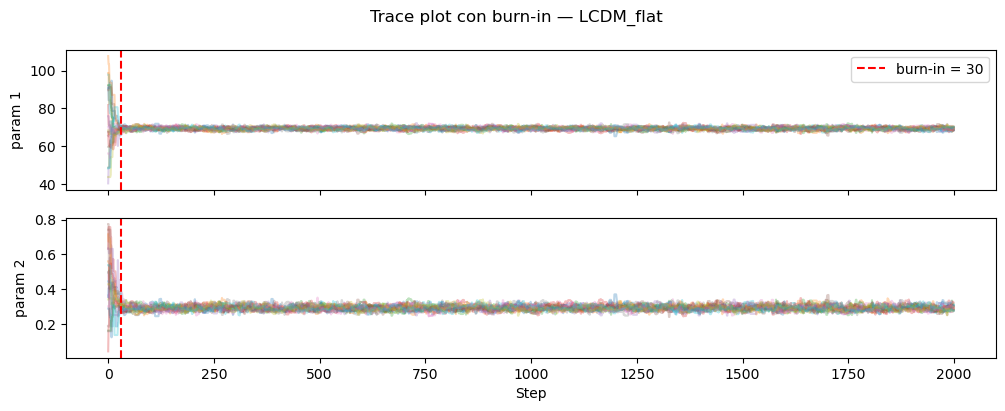

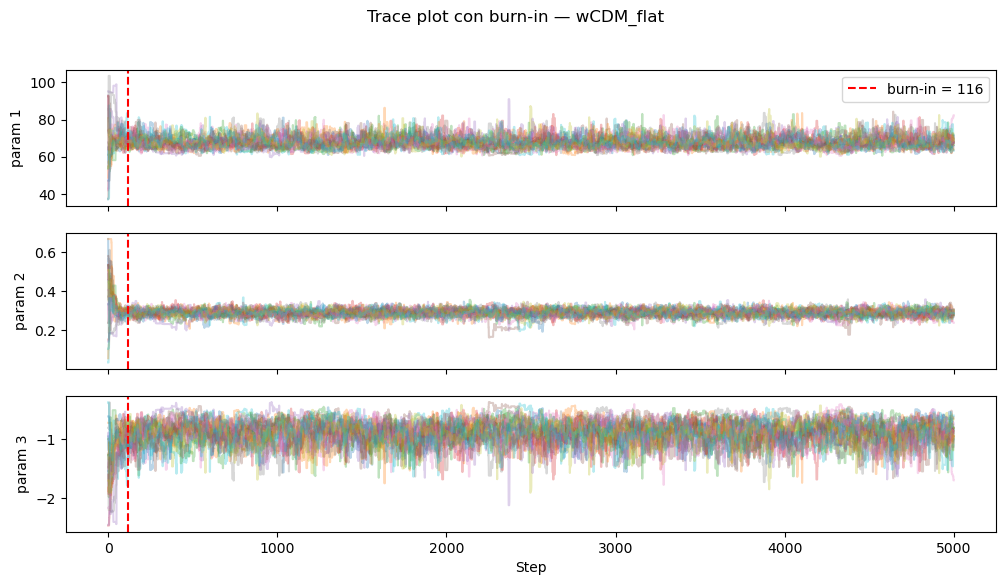

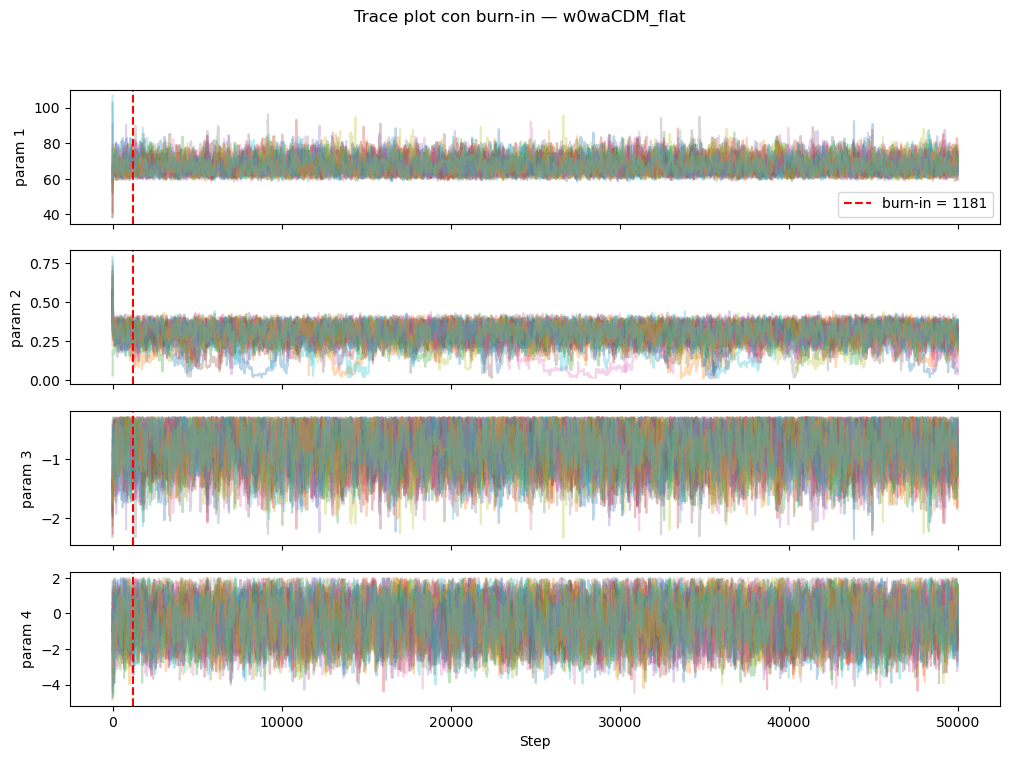

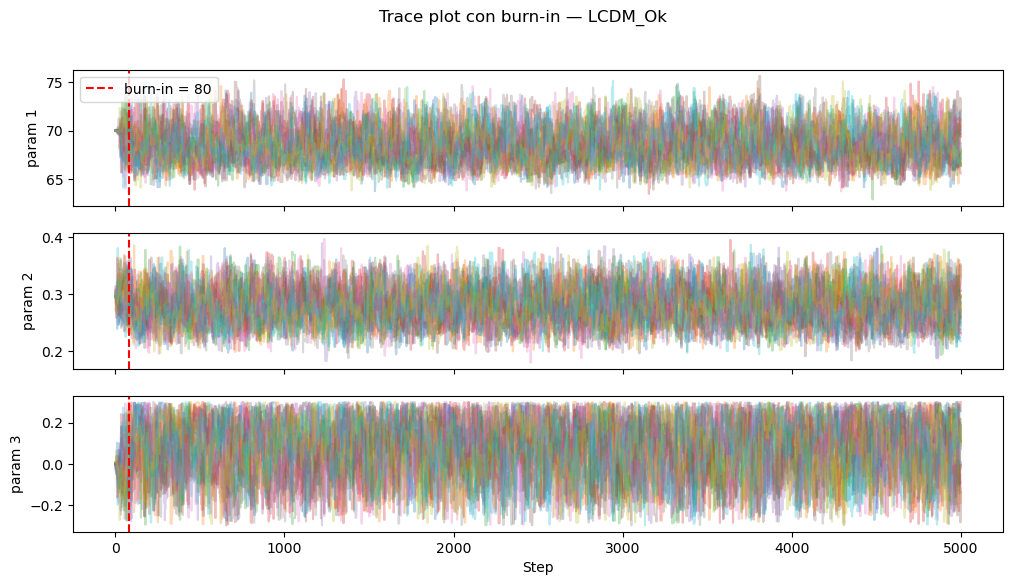

In [40]:
import numpy as np
import matplotlib.pyplot as plt

#voglio stampare anche il valore del burnin

for name, sampler in samplers.items():
    try:
        tau = sampler.get_autocorr_time(tol=0.05)
    except emcee.autocorr.AutocorrError:
        tau = np.full(sampler.ndim, 100.0)

    tau_max = np.max(tau) 
    if not np.isfinite(tau_max):
        tau_max = 100.0

    burnin = int(2 * tau_max)

    chain = sampler.get_chain()
    nwalk, ndim = chain.shape[1], chain.shape[2]

    fig, axes = plt.subplots(ndim, figsize=(12, 2 * ndim), sharex=True)

    for i in range(ndim):
        for walker in range(nwalk):
            axes[i].plot(chain[:, walker, i], alpha=0.3)
        axes[i].axvline(burnin, color='red', linestyle='--', label=f"burn-in = {burnin}")
        axes[i].set_ylabel(f'param {i+1}')

    axes[-1].set_xlabel('Step')
    axes[0].legend()
    fig.suptitle(f'Trace plot con burn-in — {name}')
    plt.show()


## I PLOT

Dopo aver verificato che le catene siano convergenti, si eseguono i due plot con la stessa strategia dell’Esempio 1. Nel secondo plot, oltre alla curva di **best-fit** definita dalla mediana di ciascun parametro, viene tracciata anche la curva **MAP** (Maximum A Posteriori), corrispondente al punto di massima densità della posteriori:  
$$
\theta_{\rm MAP} \;=\;\arg\max_{\theta}\,p(\theta\mid D)\,.
$$  
Questa stima coincide con la moda della distribuzione. Lo svantaggio nell’usare la MAP come “miglior valore” è che, essendo localizzata in un picco di piccolo volume, può non rappresentare adeguatamente la forma complessiva della posteriori, a differenza della mediana che riflette l’intero volume della distribuzione.  


In [41]:
scatter_map = {
    "black": "dimgray",
    "cyan":  "lightcyan",
    "green": "lightgreen",
    "red":   "lightcoral",
    "purple":"plum",
    "orange":"moccasin",
}


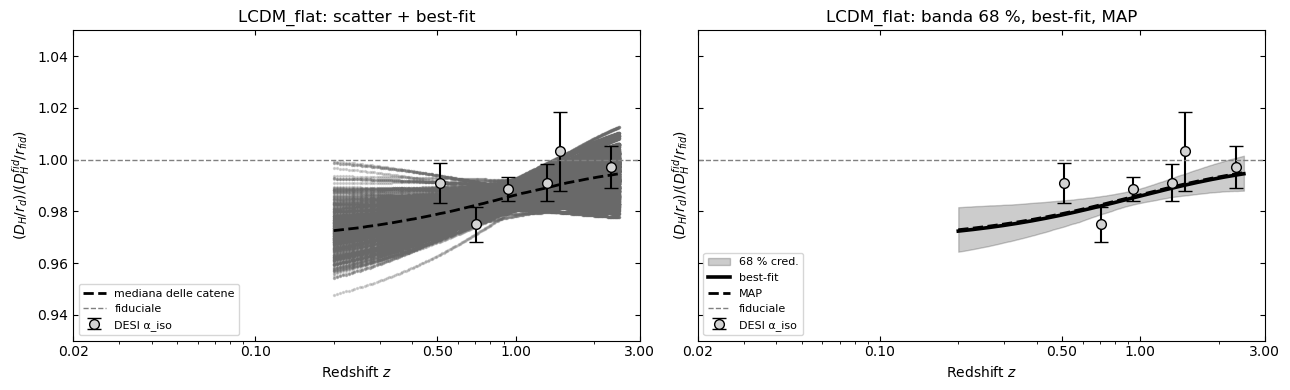

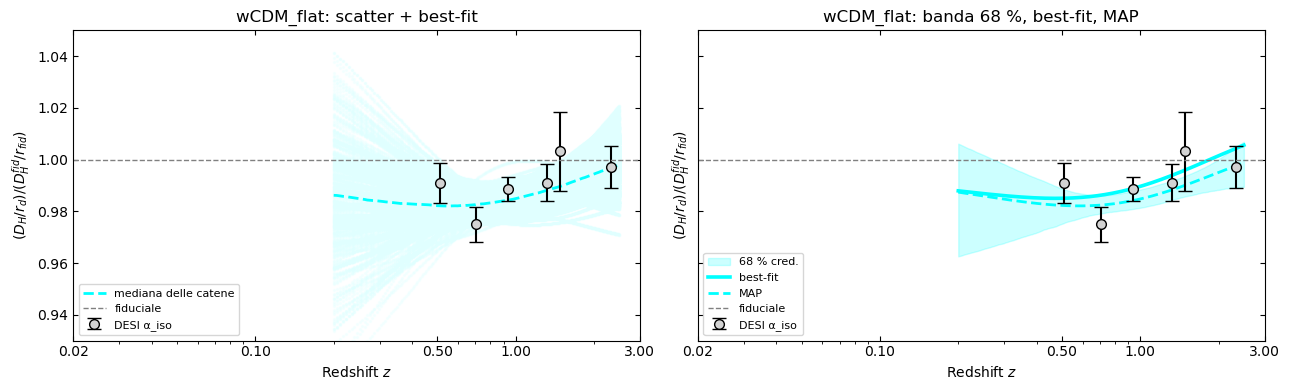

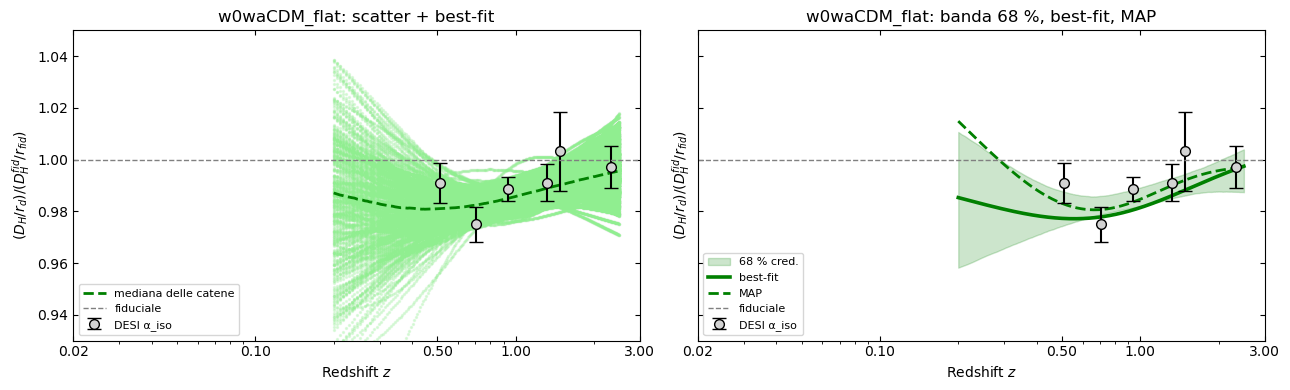

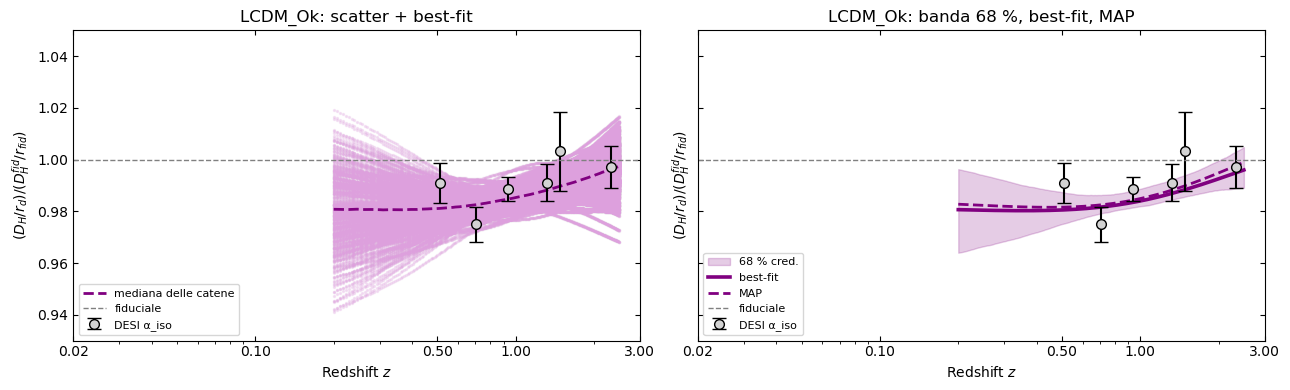

In [42]:
burn, N_scat, N_band = nsteps//3, 300, 2000
z_dense      = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_model(z_dense, fid_cosmo)
results = {}

for name, cfg in models.items():
    tag, col = cfg["tag"], cfg["color"]
    chain    = samplers[name].get_chain(discard=burn, flat=True)
    if chain.size == 0:
        continue

    # mediana (best-fit) e MAP 
    best_med = np.median(chain, axis=0)
    logp     = samplers[name].get_log_prob(discard=burn, flat=True)
    best_map = chain[np.argmax(logp)]

    p16, p50, p84 = np.percentile(chain, [16, 50, 84], axis=0)
    results[name] = dict(tag=tag, p16=p16, p50=p50, p84=p84,
                         best=best_med, map=best_map)

    α_best = dv_rd_model(z_dense, build_cosmo_new(best_med, tag)) / (Dv_fid_dense/r_d_fid)
    α_map  = dv_rd_model(z_dense, build_cosmo_new(best_map, tag)) / (Dv_fid_dense/r_d_fid)

    idx_b  = rng.choice(chain.shape[0], size=min(N_band, chain.shape[0]), replace=False)
    α_mat  = np.array([
        dv_rd_model(z_dense, build_cosmo_new(th, tag)) / (Dv_fid_dense/r_d_fid)
        for th in chain[idx_b]
    ])
    α_low, α_med_fun, α_high = np.percentile(α_mat, [16,50,84], axis=0)

    idx_s  = rng.choice(chain.shape[0], size=min(N_scat, chain.shape[0]), replace=False)
    col_s  = (*plt.matplotlib.colors.to_rgb(scatter_map.get(col,"lightgray")), 0.25)

    fig, (axL, axR) = plt.subplots(1,2, figsize=(13,4), sharey=True)

    # SINISTRA
    for th in chain[idx_s]:
        α = dv_rd_model(z_dense, build_cosmo_new(th, tag)) / (Dv_fid_dense/r_d_fid)
        axL.scatter(z_dense, α, s=2, color=col_s)
    axL.plot(z_dense, α_med_fun, ls="--", lw=2.0, color=col, label="mediana delle catene")

    # DESTRA 
    axR.fill_between(z_dense, α_low, α_high, color=col, alpha=0.20, label="68 % cred.")
    axR.plot(z_dense, α_best, lw=2.6, color=col, label="best-fit")
    axR.plot(z_dense, α_map, ls="--", lw=2.0, color=col, label="MAP")

    for ax in (axL, axR):
        ax.errorbar(z_data, alpha_data, yerr=alpha_sigma,
                    fmt="o", ms=7, mfc="lightgray", mec="k",
                    ecolor="k", capsize=5, label="DESI α_iso")
        ax.axhline(1, ls="--", lw=1, color="grey", label="fiduciale")
        ax.set_xscale("log")
        ax.set_xlabel("Redshift $z$")
        ax.set_ylabel(r'$(D_H/r_d)/(D_H^{fid}/r_{fid})$')
        ax.set_xlim(0.2, 2.5); ax.set_ylim(0.93, 1.05)
        ax.set_xticks([0.02, 0.1, 0.5, 1, 3])
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.tick_params(axis='both', direction='in', top=True, right=True)
        ax.legend(fontsize=8, loc='lower left')

    axL.set_title(f"{name}: scatter + best-fit")
    axR.set_title(f"{name}: banda 68 %, best-fit, MAP")
    fig.tight_layout();  plt.show()



Si può notare dai grafici come per il modello **ΛCDM** le curve **best-fit** e **MAP** coincidano: con soli due parametri ben determinati la posteriori è pressoché gaussiana, per cui la mediana e la moda (punto di massima densità) ricadono nello stesso istante.  

Nei modelli **wCDM** e **ΛCDM_Ok** le due curve restano molto vicine, poiché, pur discostandosi leggermente dalla forma gaussiana, il volume della regione ad alta densità e il picco principale sono ancora allineati.  

Nel caso di $w_{0}w_{a}$**CDM**, invece, le curve **best-fit** e **MAP** sono significativamente diverse. Con quattro parametri e dati BAO relativamente scarsi, la posteriori multidimensionale può presentare code lunghe o più picchi, e mentre la **MAP** sarà localizzata nel picco più alto, la mediana può rimanere in una zona a bassa densità tra i due picchi. È importante ricordare che la stima **MAP** individua un *singolo punto* $\theta_{\rm MAP}$ nello spazio multidimensionale dei parametri, corrispondente al massimo di densità della distribuzione congiunta 
$$
p(\theta_1,\dots,\theta_n \mid D).
$$
La **mediana** di ciascun parametro $\theta_i$ , invece, deriva da una proiezione dell’intera distribuzione multidimensionale a quella 1D di ogni singolo parametro e questo processo si compie integrando via le altre $n-1$ variabili:
$$
p(\theta_i\mid D)
=\int p(\theta\mid D)\,\mathrm{d}\theta_1\cdots\mathrm{d}\theta_{i-1}\,\mathrm{d}\theta_{i+1}\cdots\mathrm{d}\theta_n,
$$
e calcolando il 50° percentile di questa distribuzione 1D.  

La proiezione di una distribuzione congiunta complessa su una singola dimensione può spostare il picco di $p(\theta_i\mid D)$ rispetto al corrispondente componente di $\theta_{\rm MAP}$. 
Questo fenomeno è noto come **effetto di proiezione**, ed è particolarmente pronunciato quando la posteriori presenta code lunghe o più picchi, o quando i dati non sono sufficientemente informativi per definire congiuntamente tutte le direzioni nello spazio dei parametri.  



## I CORNER PLOT 
Con i corner plot otteniamo una rappresentazione simultanea delle distribuzioni marginali e congiunte dei parametri:

- Gli **istogrammi 1D** mostrano la distribuzione marginale $ p(\theta_i \mid D) $ di ciascun parametro, evidenziando picchi, code e intervalli di credibilità.

- I **contorni 2D** tracciano le curve di livello della densità congiunta $p(\theta_i, \theta_j \mid D) $.
  - Un contorno **ellittico** indica una correlazione lineare fra $\theta_i$ e $\theta_j$, vuol dire che la relazione tra i parametri è tipicamente descritta da 
    $$
    \theta_j = a\,\theta_i + b
    $$
    se uno aumenta l'altro aumenta/diminuisce in modo lineare.
  - Un contorno **distorto** o a “boomerang”, con curvature e code, segnala correlazioni non lineari e relazioni più complesse, che possono essere ad esempio 
   $$
    \theta_j = a\,\theta_i^2 + b \; \text{o} \; \theta_j = a\sqrt{\theta_i} + c
    $$
Contorni fortemente deformati o multimodali rivelano degenerazioni: indicano che i dati non forniscono sufficiente informazione per rompere le correlazioni fra i parametri.  
Nei corner plot, oltre agli istogrammi marginali di ciascun parametro, tracciamo:

- Una linea colorata (es. blu) alla posizione del **best‐fit** 
- Una linea rossa alla posizione del **MAP**
- Linee tratteggiate che delimitano i **16° e 84° percentile** di ogni distribuzione marginale, corrispondenti all’intervallo di credibilità al 68%.

La stima **MAP** è definita come il punto di massima densità nella distribuzione **congiunta** multidimensionale. Quando proiettiamo $\theta_{\rm MAP}$ su ciascuna coordinata,
$$
\theta_{\rm MAP,i}
=\bigl[\theta_{\rm MAP}\bigr]_i
$$
otteniamo valori che non coincidono in generale con la moda della distribuzione **marginale**. Di conseguenza la linea rossa del MAP può apparire in regioni di bassa densità marginale: questo accade perché la **moda congiunta** non è la stessa della **moda marginale**, soprattutto in presenza di code lunghe, picchi multipli o forti correlazioni tra parametri.  

In [43]:
labels_dict = {
    "LCDM_flat":    [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$"],
    "wCDM_flat":    [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$w$"],
    "w0waCDM_flat": [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$w_0$", r"$w_a$"],
    "LCDM_Ok":      [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$\Omega_k$"],
    "w0wa_Ok":      [r"$H_0\ [\mathrm{km/s/Mpc}]$", r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"],
}


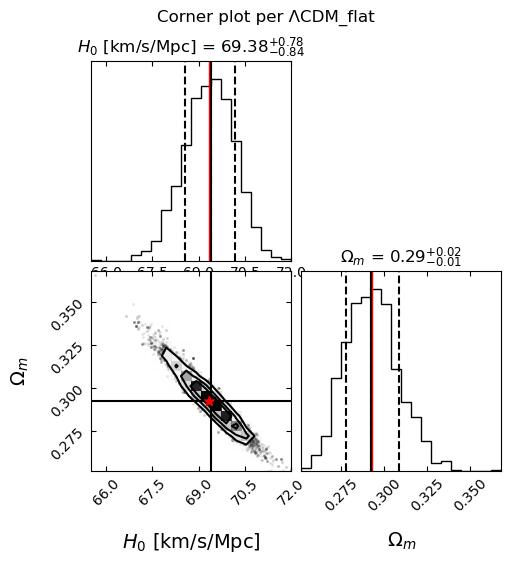

In [ ]:
burn = nsteps // 3
name = "LCDM_flat"
cfg  = models[name]
sampler = samplers[name]
chain   = sampler.get_chain(discard=burn, flat=True)

logp      = sampler.get_log_prob(discard=burn, flat=True)
map_idx   = np.argmax(logp)
theta_map = chain[map_idx]
theta_med = np.median(chain, axis=0)

fig = corner.corner(
    chain,
    labels       = labels_dict[name],
    truths       = theta_med,
    truth_color  = cfg["color"],
    truth_kwargs = {"linestyle":"--","linewidth":2},
    show_titles  = True,
    quantiles    = [0.16, 0.5, 0.84],
    title_fmt    = ".2f",
    title_kwargs = {"fontsize":12},
    label_kwargs = {"fontsize":14}
)

axes = np.array(fig.axes).reshape((cfg["ndim"], cfg["ndim"]))
for i in range(cfg["ndim"]):
    axes[i, i].axvline(theta_map[i], color="red", linewidth=1)
for yi in range(cfg["ndim"]):
    for xi in range(yi):
        axes[yi, xi].scatter(theta_map[xi], theta_map[yi],
                             color="red", marker="*", s=50, zorder=10)

fig.suptitle("Corner plot per ΛCDM_flat", y=1.02)
for ax in fig.axes:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(direction='in', top=True, right=True)

plt.show()


Nel modello ΛCDM fissiamo il sound horizon $r_d$, il che ci permette di determinare con precisione i due parametri $H_0$ e $\Omega_m$ a partire dai dati BAO. Le distribuzioni marginali di $H_0$ e $\Omega_m$ appaiono entrambe gaussiane, mentre il grafico 2D forma un’ellisse inclinata di $-45^\circ$ , segno di una correlazione lineare negativa tra i parametri. Formalmente, il coefficiente di correlazione soddisfa $\rho(H_0,\Omega_m)<0$. 
Questo anticorrelazione nasce dalla definizione di  
$$
D_V(z)\;=\;\Bigl[(1+z)^2\,D_M^2(z)\,\frac{c\,z}{H(z)}\Bigr]^{1/3}\,,
$$
per cui un aumento di $H_0$ deve essere compensato da una riduzione di $\Omega_m$ per mantenere $D_V(z)$ costante e riprodurre il picco BAO osservato.

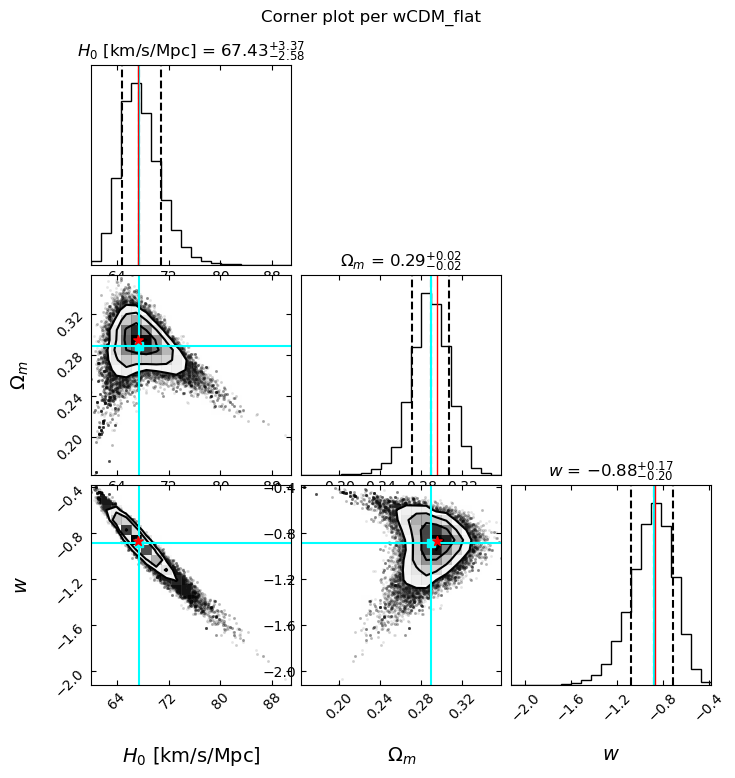

In [ ]:
burn = nsteps // 3
name = "wCDM_flat"
cfg  = models[name]
sampler = samplers[name]
chain   = sampler.get_chain(discard=burn, flat=True)

logp      = sampler.get_log_prob(discard=burn, flat=True)
map_idx   = np.argmax(logp)
theta_map = chain[map_idx]
theta_med = np.median(chain, axis=0)

fig = corner.corner(
    chain,
    labels       = labels_dict[name],
    truths       = theta_med,
    truth_color  = cfg["color"],
    truth_kwargs = {"linestyle":"--","linewidth":2},
    show_titles  = True,
    quantiles    = [0.16, 0.5, 0.84],
    title_fmt    = ".2f",
    title_kwargs = {"fontsize":12},
    label_kwargs = {"fontsize":14}
)

axes = np.array(fig.axes).reshape((cfg["ndim"], cfg["ndim"]))
for i in range(cfg["ndim"]):
    axes[i, i].axvline(theta_map[i], color="red", linewidth=1)
for yi in range(cfg["ndim"]):
    for xi in range(yi):
        axes[yi, xi].scatter(theta_map[xi], theta_map[yi],
                             color="red", marker="*", s=50, zorder=10)

fig.suptitle("Corner plot per wCDM_flat", y=1.02)
for ax in fig.axes:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(direction='in', top=True, right=True)

plt.show()


Nel modello **wCDM** introduciamo il parametro $w$, mantenendo fissato il $r_d$. Questo allarga lo spazio dei parametri e riduce leggermente il potere di vincolo su $H_0$ e $\Omega_m$, che appaiono ora meno strettamente correlati rispetto a ΛCDM. Il fatto di avere $r_d$ fissato garantisce comunque una forte ancoratura delle distanze e permette di ottenere comunque un intervallo sensato per $w$.

Osserviamo nel corner plot che:

- **$\Omega_m$ vs. $w$**: la correlazione è molto debole, perché i dati BAO isotropici sono poco sensibili a variazioni moderate di $w$.  
- **$H_0$ vs. $\Omega_m$**: l’anticorrelazione tipica di ΛCDM si attenua.  
- **$H_0$ vs. $w$**: persiste un’anticorrelazione netta, poiché un aumento di $H_0$ (espansione più rapida) deve essere compensato da un valore di $w$ più basso (energia oscura più “attrattiva”) per mantenere costante il volume in cui si manifesta il picco BAO. Quindi aggiungere $w$ dilata le distribuzioni marginali, attenua alcune degenerazioni ma conserva le principali relazioni tra i parametri, in particolare l’anticorrelazione lineare fra $H_0$ e $w$.

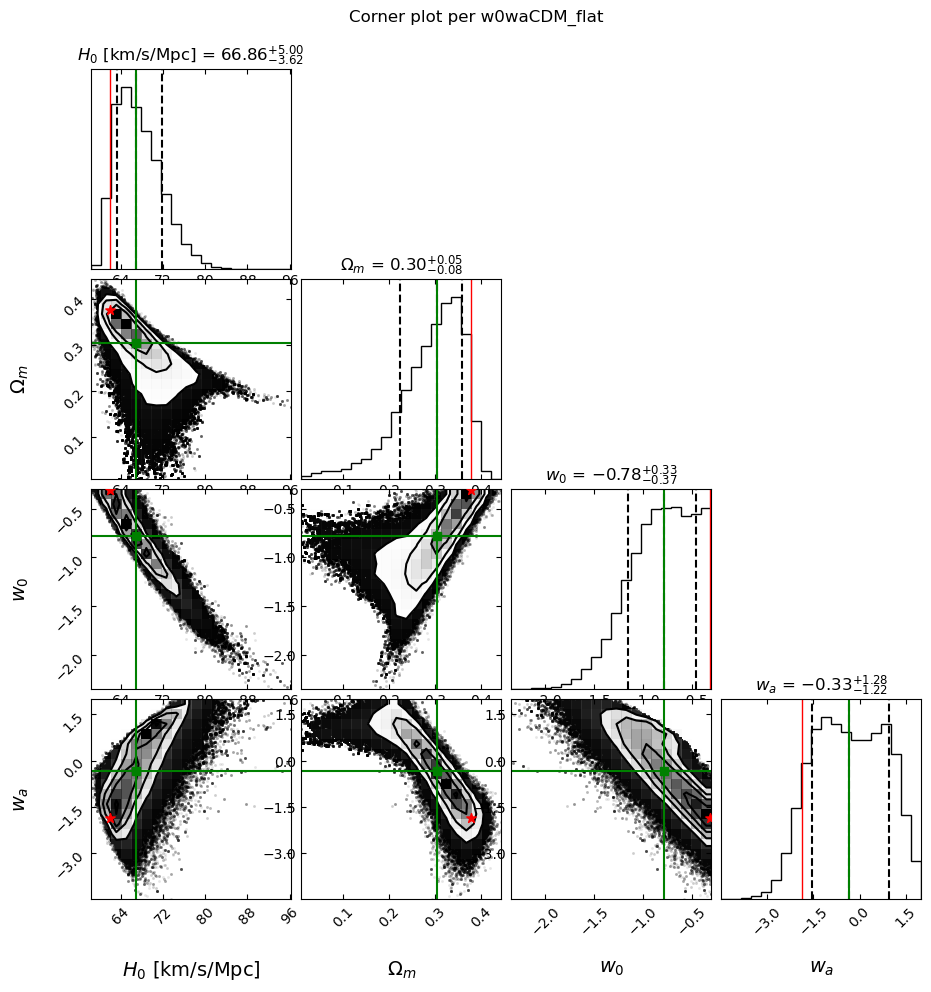

In [ ]:
burn = nsteps // 3
name = "w0waCDM_flat"
cfg  = models[name]
sampler = samplers[name]
chain   = sampler.get_chain(discard=burn, flat=True)

logp      = sampler.get_log_prob(discard=burn, flat=True)
map_idx   = np.argmax(logp)
theta_map = chain[map_idx]
theta_med = np.median(chain, axis=0)

fig = corner.corner(
    chain,
    labels       = labels_dict[name],
    truths       = theta_med,
    truth_color  = cfg["color"],
    truth_kwargs = {"linestyle":"--","linewidth":2},
    show_titles  = True,
    quantiles    = [0.16, 0.5, 0.84],
    title_fmt    = ".2f",
    title_kwargs = {"fontsize":12},
    label_kwargs = {"fontsize":14}
)

axes = np.array(fig.axes).reshape((cfg["ndim"], cfg["ndim"]))
for i in range(cfg["ndim"]):
    axes[i, i].axvline(theta_map[i], color="red", linewidth=1)
for yi in range(cfg["ndim"]):
    for xi in range(yi):
        axes[yi, xi].scatter(theta_map[xi], theta_map[yi],
                             color="red", marker="*", s=50, zorder=10)

fig.suptitle("Corner plot per w0waCDM_flat", y=1.02)
for ax in fig.axes:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(direction='in', top=True, right=True)

plt.show()


Nel corner plot per il modello **w₀wₐCDM** le distribuzioni marginali in 1D non sono più gaussiane: si osservano più picchi e code estese. Di conseguenza, le linee che indicano la **mediana** e la **MAP** sono molto distanziate tra loro.

I parametri non presentano correlazioni lineari uniformi: le forme distorte e frammentate mostrano che i dati BAO, pur ancorati al sound horizon, non bastano a determinare con precisione ogni parametro. Tuttavia, l’inclinazione dei contorni 2D rivela correlazioni locali.  

Ad esempio, tra $w_0$ e $w_a$ si evidenzia una **anticorrelazione**, perché la combinazione  
$$
  w(a) = w_0 + w_a\,(1-a)
$$
è ben fissata intorno a un redshift pivot $a_{\rm pivot}$. Un $w_0$ più negativo deve essere compensato da un $w_a$ più positivo per mantenere costante $w(a_{\rm pivot})$, generando un contorno inclinato con pendenza negativa.  

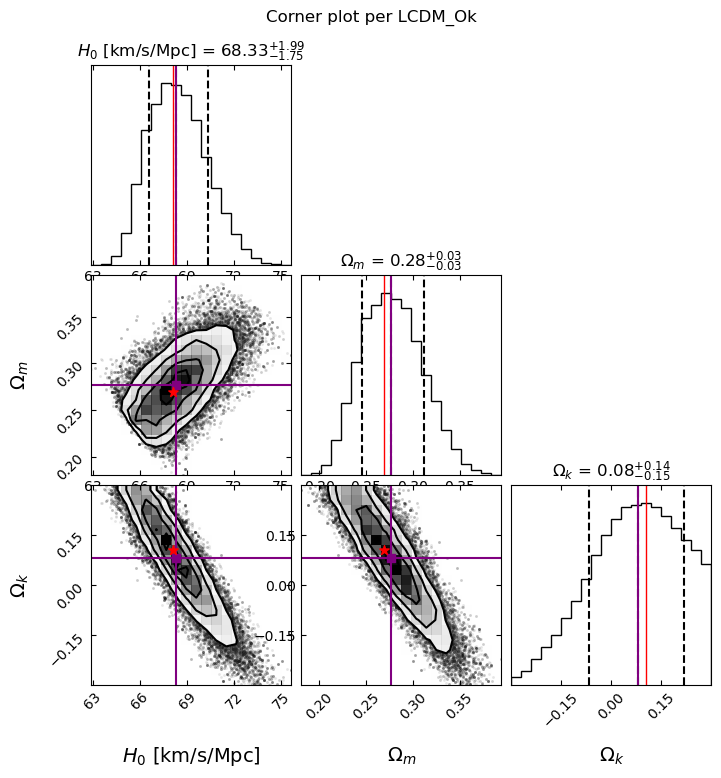

In [ ]:
burn = nsteps // 3
name = "LCDM_Ok"
cfg  = models[name]
sampler = samplers[name]
chain   = sampler.get_chain(discard=burn, flat=True)

logp      = sampler.get_log_prob(discard=burn, flat=True)
map_idx   = np.argmax(logp)
theta_map = chain[map_idx]
theta_med = np.median(chain, axis=0)

fig = corner.corner(
    chain,
    labels       = labels_dict[name],
    truths       = theta_med,
    truth_color  = cfg["color"],
    truth_kwargs = {"linestyle":"--","linewidth":2},
    show_titles  = True,
    quantiles    = [0.16, 0.5, 0.84],
    title_fmt    = ".2f",
    title_kwargs = {"fontsize":12},
    label_kwargs = {"fontsize":14}
)

axes = np.array(fig.axes).reshape((cfg["ndim"], cfg["ndim"]))
for i in range(cfg["ndim"]):
    axes[i, i].axvline(theta_map[i], color="red", linewidth=1)
for yi in range(cfg["ndim"]):
    for xi in range(yi):
        axes[yi, xi].scatter(theta_map[xi], theta_map[yi],
                             color="red", marker="*", s=50, zorder=10)

fig.suptitle("Corner plot per LCDM_Ok", y=1.02)
for ax in fig.axes:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(direction='in', top=True, right=True)

plt.show()


Nel modello ΛCDM con curvatura libera ($\Omega_K \neq 0$) l’introduzione di $\Omega_K$ comporta una perdita di informazione meno pronunciata rispetto all’aggiunta di $w$, perciò i contorni 2D rimangono essenzialmente ellittici. Infatti, la nuova forma dell’equazione di Friedmann  

$$  
H^2(z) = H_0^2\bigl[\Omega_m(1+z)^3 + \Omega_K(1+z)^2 + (1 - \Omega_m - \Omega_K)\bigr]  
$$  

mostra che un aumento simultaneo di $H_0$ e $\Omega_m$ può essere bilanciato da una variazione di $\Omega_K$ in modo da mantenere costante $H(z)$ (e quindi $D_V(z)$), generando nei plot 2D un’ellisse inclinata con pendenza positiva tra $H_0$ e $\Omega_m$. Allo stesso tempo, ricordo di aver imposto nell prior  

$$  
\Omega_\Lambda = 1 - \Omega_m - \Omega_K \ge 0  
\quad\Longrightarrow\quad  
\Omega_K \le 1 - \Omega_m  
$$  

in modo da escludere tutte le cosmologie con densità di energia oscura negativa: nei pannelli 2D la densità di campioni si azzera bruscamente lungo la retta $\Omega_K = 1 - \Omega_m$, troncando l’ellisse. Inoltre, un incremento di $\Omega_K$ deve essere compensato da una diminuzione di $H_0$ per riprodurre lo stesso tasso di espansione, producendo un’anticorrelazione (ellisse inclinata negativamente) nel pannello $\Omega_K$ vs $H_0$.  









In [ ]:
def f(mu, lo, hi, nd=3):
    return f"{mu:.{nd}f} (+{hi-mu:.{nd}f}/-{mu-lo:.{nd}f})"

print("\n=== Parametri cosmologici ===")
for name, d in results.items():
    tag,p16,p50,p84,mp = d["tag"],d["p16"],d["p50"],d["p84"],d["map"]
    if tag == "lcdm":
        print(f"{name}:  H0={f(p50[0],p16[0],p84[0],2)}  "
              f"Ωm={f(p50[1],p16[1],p84[1])}  "
              f"|  MAP: H0={mp[0]:.2f}, Ωm={mp[1]:.3f}")
    elif tag == "lcdm_ok":
        print(f"{name}:  H0={f(p50[0],p16[0],p84[0],2)}  "
              f"Ωm={f(p50[1],p16[1],p84[1])}  Ωk={f(p50[2],p16[2],p84[2])}  "
              f"|  MAP: {mp[0]:.2f}, {mp[1]:.3f}, {mp[2]:+.3f}")
    elif tag == "wcdm":
        print(f"{name}:  H0={f(p50[0],p16[0],p84[0],2)}  "
              f"Ωm={f(p50[1],p16[1],p84[1])}  w0={f(p50[2],p16[2],p84[2],2)}  "
              f"|  MAP: {mp[0]:.2f}, {mp[1]:.3f}, {mp[2]:+.2f}")
    else: 
        labs = ("H0","Ωm","w0","wa") + (("Ωk",) if "ok" in tag else ())
        med  = "  ".join(f"{lab}={f(p50[i],p16[i],p84[i],2 if lab=='H0' else 3)}"
                         for i,lab in enumerate(labs))
        map_s = ", ".join(f"{v:+.3f}" if i else f"{v:.2f}" for i,v in enumerate(mp))
        print(f"{name}:  {med}  |  MAP: {map_s}")



=== Parametri cosmologici ===
LCDM_flat:  H0=69.30 (+0.81/-0.81)  Ωm=0.293 (+0.015/-0.014)  |  MAP: H0=69.39, Ωm=0.292
wCDM_flat:  H0=67.56 (+3.43/-2.74)  Ωm=0.289 (+0.017/-0.018)  w0=-0.89 (+0.18/-0.20)  |  MAP: 67.36, 0.295, -0.87
w0waCDM_flat:  H0=67.09 (+4.89/-3.73)  Ωm=0.300 (+0.055/-0.080)  w0=-0.802 (+0.338/-0.350)  wa=-0.257 (+1.247/-1.263)  |  MAP: 61.90, +0.378, -0.309, -1.894
LCDM_Ok:  H0=68.36 (+2.01/-1.74)  Ωm=0.277 (+0.035/-0.031)  Ωk=0.078 (+0.136/-0.147)  |  MAP: 68.01, 0.269, +0.109


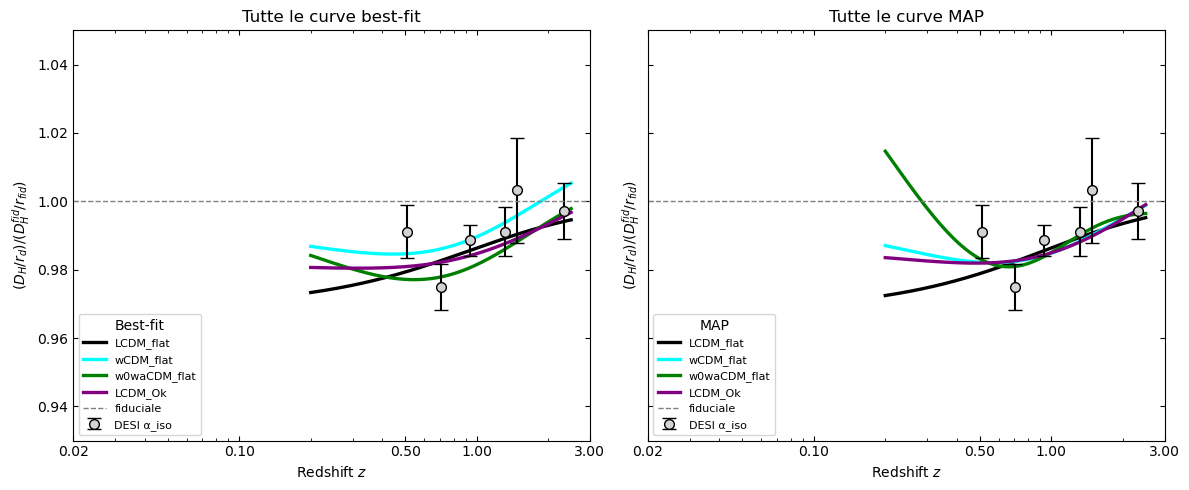

In [ ]:
z_dense      = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_model(z_dense, fid_cosmo)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for name, cfg in models.items():
    if name not in results:    
        continue
    tag      = cfg["tag"]
    col_line = cfg["color"]

    best_med = results[name]["best"]
    α_best   = dv_rd_model(z_dense, build_cosmo_new(best_med, tag)) / \
               (Dv_fid_dense / r_d_fid)
    axL.plot(z_dense, α_best, lw=2.4, color=col_line,
             label=f"{name}")
    
    best_map = results[name]["map"]
    α_map    = dv_rd_model(z_dense, build_cosmo_new(best_map, tag)) / \
               (Dv_fid_dense / r_d_fid)
    axR.plot(z_dense, α_map, lw=2.4, color=col_line,
             label=f"{name}")

for ax in (axL, axR):
    ax.errorbar(z_data, alpha_data, yerr=alpha_sigma,
                fmt="o", ms=7, mfc="lightgray", mec="k",
                ecolor="k", capsize=5, label="DESI α_iso")
    ax.axhline(1, ls="--", lw=1, color="grey", label="fiduciale")
    ax.set_xscale("log")
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r'$(D_H/r_d)/(D_H^{fid}/r_{fid})$')
    ax.set_xlim(0.2, 2.5); ax.set_ylim(0.93, 1.05)
    ax.set_xticks([0.02, 0.1, 0.5, 1, 3])
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    for s in ax.spines.values(): s.set_visible(True)
    ax.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

axL.legend(title="Best-fit", fontsize=8, loc='lower left')
axR.legend(title="MAP", fontsize=8, loc='lower left')

axL.set_title("Tutte le curve best-fit")
axR.set_title("Tutte le curve MAP")
fig.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

desi_ref = pd.read_csv("desi_reference_cosmos.csv")

family_map = {
    "LCDM_flat"   : "LCDM",
    "LCDM_Ok"     : "LCDM+Ok",
    "wCDM_flat"   : "wCDM",
    "w0wa_DESI"   : "w0waCDM",
    "w0wa_lit"    : "w0waCDM",
    "w0wa_Ok"     : "w0waCDM+Ok",
}

my_rows = []
for name, d in results.items():                    
    fam   = family_map.get(name)
    if fam is None: continue
    pars  = d["map"]                                 
    my_rows.append({"family": fam, "H0_my": pars[0], "Om_my": pars[1]})

my_df = pd.DataFrame(my_rows).drop_duplicates("family")

for _, my in my_df.iterrows():
    fam      = my["family"]
    theirs   = desi_ref[desi_ref["model"] == fam].copy()

    theirs["H0_my"] = my["H0_my"]
    theirs["Om_my"] = my["Om_my"]

    theirs["ΔH0 (%)"] = 100*(theirs["H0_my"] - theirs["H0"])/theirs["H0"]
    theirs["ΔOm (%)"] = 100*(theirs["Om_my"] - theirs["Om"])/theirs["Om"]

    theirs["dist2"] = theirs["ΔH0 (%)"]**2 + theirs["ΔOm (%)"]**2
    best_row = theirs.loc[theirs["dist2"].idxmin()]
    best_ds  = best_row["dataset"]
    best_pct = np.sqrt(best_row["dist2"])

    print(f"\n=== {fam}: confronto tuo modello ↔ DESI ===")
    display(theirs[["dataset","H0","H0_my","ΔH0 (%)",
                    "Om","Om_my","ΔOm (%)"]].round(3))

    print(f"→ Dataset DESI più vicino: **{best_ds}**  "
          f"(distanza ≈ {best_pct:.2f} %)\n")



=== LCDM: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
0,CMB,67.14,69.386,3.346,0.317,0.292,-7.902
1,DESI,68.50,69.386,1.294,0.298,0.292,-1.896
2,DESI+BBN,68.45,69.386,1.368,0.297,0.292,-1.631
3,DESI+CMB,68.17,69.386,1.784,0.303,0.292,-3.581


→ Dataset DESI più vicino: **DESI+BBN**  (distanza ≈ 2.13 %)


=== wCDM: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
7,CMB,65.80,67.364,2.377,0.296,0.295,-0.392
8,DESI,69.10,67.364,-2.512,0.300,0.295,-1.687
9,DESI+CMB,69.51,67.364,-3.087,0.297,0.295,-0.727


→ Dataset DESI più vicino: **CMB**  (distanza ≈ 2.41 %)


=== LCDM+Ok: confronto tuo modello ↔ DESI ===


,dataset,H0,H0_my,ΔH0 (%),Om,Om_my,ΔOm (%)
4,CMB,63.3,68.013,7.446,0.354,0.269,-24.038
5,DESI,69.1,68.013,-1.573,0.293,0.269,-8.223
6,DESI+CMB,68.5,68.013,-0.711,0.303,0.269,-11.369


→ Dataset DESI più vicino: **DESI**  (distanza ≈ 8.37 %)

